# Portfolio problem

In [1]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import AlgorithmColor


In [2]:
# mmc2_dir = Path("/", "Users", "patrick", "Datasets", "misdro", "mmc2")
mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
dgp = "DowJones"
returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

returns_df

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0.007383,0.012783,0.005208,-0.038285,-0.012098,-0.056079,-0.041475,-0.032967,-0.023324,0.010955,...,0.024652,-0.027021,-0.015650,-0.009319,-0.027835,-0.026883,-0.008618,0.006533,0.051115,0.004274
1,0.014659,0.060496,-0.041451,0.014044,0.008151,0.003959,0.014423,0.039771,0.071641,0.014441,...,-0.108267,0.015873,0.023849,0.041915,0.063393,0.050251,-0.043478,0.012988,0.054975,0.046809
2,0.061602,0.028454,0.005405,0.023102,0.010126,0.011830,0.018950,0.016396,0.036207,0.026693,...,0.067451,0.000000,0.017083,0.107200,0.030769,0.040666,0.018176,0.022436,-0.018046,-0.002036
3,0.157034,0.076217,0.021505,0.029342,0.040078,0.052638,-0.037206,-0.013443,0.016138,0.045055,...,-0.037913,0.023438,0.015268,0.048307,0.067165,0.032176,0.000000,-0.018807,0.004088,0.002040
4,-0.002973,-0.042887,-0.036842,-0.019733,-0.013486,0.009256,-0.057971,0.002724,-0.010582,-0.013267,...,-0.013136,-0.041991,0.007514,0.007680,0.006994,0.008909,-0.040180,-0.022364,0.006101,-0.052846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,0.053573,0.002948,0.053774,0.014542,0.039465,0.034998,0.064654,0.029174,0.023364,0.020403,...,0.022334,-0.000341,0.023586,-0.037993,0.039939,0.003105,0.061533,0.063085,0.104431,0.026879
1359,0.006381,0.041936,-0.024272,0.008619,-0.000660,-0.023225,-0.013680,0.006321,-0.007807,0.029084,...,0.028417,0.049082,0.007722,0.026329,0.027990,-0.000929,0.009661,-0.021790,-0.027284,0.021828
1360,0.033067,0.012977,0.014683,-0.003530,0.027090,0.026488,0.022666,0.017130,0.009056,0.008390,...,0.012139,0.007404,0.018726,0.064299,0.075352,0.024166,0.027531,0.020063,0.043448,0.028452
1361,-0.006798,-0.005941,0.007175,0.008855,0.012866,-0.008401,-0.017532,-0.000749,0.002207,0.002847,...,0.017201,-0.005169,0.008736,-0.052225,-0.033638,-0.002622,-0.015194,-0.005885,-0.007511,0.001896


In [3]:
experiment_dir = Path("/dcs/large/u1508153/misdro/kl_portfolio")
assert experiment_dir.exists()
results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
results_df

mean_cost  var_cost  \
uuid                                 replication                        
9acc2ff6-addc-459b-9b04-ddfb0d32f91a 0                  inf  0.000000   
                                     1                  inf  0.000000   
                                     2                  inf  0.000000   
                                     3                  inf  0.000000   
                                     4                  inf  0.000000   
...                                                     ...       ...   
9306f7fd-142b-4381-9231-dff52c8916f0 104           0.001845  0.000179   
                                     105          -0.001873  0.000148   
                                     106          -0.006554  0.001081   
                                     107           0.007642  0.000348   
                                     108           0.001265  0.000584   

                                                                                           solution  \
uuid                                 replication                                                      
9acc2ff6-addc-459b-9b04-ddfb0d32f91a 0            [inf inf inf inf inf inf inf inf inf inf inf i...   
                                     1            [inf inf inf inf inf inf inf inf inf inf inf i...   
                                     2            [inf inf inf inf inf inf inf inf inf inf inf i...   
                                     3            [inf inf inf inf inf inf inf inf inf inf inf i...   
                                     4            [inf inf inf inf inf inf inf inf inf inf inf i...   
...                                                                                             ...   
9306f7fd-142b-4381-9231-dff52c8916f0 104          [0.027291548626341887, 0.03213678753215616, 0....   
                                     105          [0.030243438884400665, 0.03816957184538861, 0....   
                                     106          [0.0333361587521642, 0.03766409656498331, 0.03...   
                                     107          [0.036657897080418556, 0.03920218089649817, 0....   
                                     108          [0.03365161367279502, 0.02483526124986386, 0.0...   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
9acc2ff6-addc-459b-9b04-ddfb0d32f91a 0            0.673235         0.000002   
                                     1            0.276923         0.000001   
                                     2            0.275025         0.000001   
                                     3            0.364550         0.000001   
                                     4            0.271313         0.000002   
...                                                    ...              ...   
9306f7fd-142b-4381-9231-dff52c8916f0 104          0.236458         0.000001   
                                     105          0.236105         0.000001   
                                     106          0.279315         0.000001   
                                     107          0.237104         0.000001   
                                     108          0.237205         0.000001   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
9acc2ff6-addc-459b-9b04-ddfb0d32f91a 0                  0.003349    0.000025   
                                     1                  0.000630    0.000023   
                                     2                  0.000383    0.000014   
                                     3                  0.000402    0.000014   
                                     4                  0.000368    0.000014   
...                                                          ...         ...   
9306f7fd-142b-4381-9231-dff52c8916f0 104                0.002100    0.114670   
            

In [4]:
num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
num_stocks = int(len(returns_df.columns))

In [5]:
week_cols = [f"week_{i}" for i in range(OUT_OF_SAMPLE_TIME_WINDOW)]
dro_returns = {week: [] for week in week_cols}
dro_returns["uuid"] = []
dro_returns["replication"] = []
for (uuid, replication), str_cost in results_df["out_of_sample_costs"].items():
    if str_cost == "[]":
        costs = [np.nan for _ in range(OUT_OF_SAMPLE_TIME_WINDOW)]
    else:
        costs = [float(x) for x in str_cost.strip('[]').split(',')]
    dro_returns["uuid"].append(uuid)
    dro_returns["replication"].append(replication)
    for i, week in enumerate(week_cols):
        dro_returns[week].append(costs[i])
dro_returns_df = pd.DataFrame(dro_returns).set_index(["uuid", "replication"])
dro_returns_df

week_0    week_1  \
uuid                                 replication                       
9acc2ff6-addc-459b-9b04-ddfb0d32f91a 0                 NaN       NaN   
                                     1                 NaN       NaN   
                                     2                 NaN       NaN   
                                     3                 NaN       NaN   
                                     4                 NaN       NaN   
...                                                    ...       ...   
9306f7fd-142b-4381-9231-dff52c8916f0 104          0.009868 -0.024297   
                                     105          0.003496  0.002502   
                                     106          0.017377  0.005929   
                                     107          0.050680  0.022293   
                                     108          0.015893 -0.020701   

                                                    week_2    week_3  \
uuid                                 replication                       
9acc2ff6-addc-459b-9b04-ddfb0d32f91a 0                 NaN       NaN   
                                     1                 NaN       NaN   
                                     2                 NaN       NaN   
                                     3                 NaN       NaN   
                                     4                 NaN       NaN   
...                                                    ...       ...   
9306f7fd-142b-4381-9231-dff52c8916f0 104          0.019263  0.020621   
                                     105          0.003934 -0.000744   
                                     106         -0.033696  0.010995   
                                     107          0.003603  0.027736   
                                     108         -0.040267 -0.021895   

                                                    week_4    week_5  \
uuid                                 replication                       
9acc2ff6-addc-459b-9b04-ddfb0d32f91a 0                 NaN       NaN   
                                     1                 NaN       NaN   
                                     2                 NaN       NaN   
                                     3                 NaN       NaN   
                                     4                 NaN       NaN   
...                                                    ...       ...   
9306f7fd-142b-4381-9231-dff52c8916f0 104          0.003210  0.010580   
                                     105          0.009701 -0.005232   
                                     106          0.002695 -0.001943   
                                     107          0.012123 -0.008600   
                                     108         -0.004321  0.032389   

                                                    week_6    week_7  \
uuid                                 replication                       
9acc2ff6-addc-459b-9b04-ddfb0d32f91a 0                 NaN       NaN   
                                     1                 NaN       NaN   
                                     2                 NaN       NaN   
                                     3                 NaN       NaN   
                                     4                 NaN       NaN   
...                                                    ...       ...   
9306f7fd-142b-4381-9231-dff52c8916f0 104         -0.017301 -0.003395   
                                     105         -0.008831 -0.019390   
                                     106         -0.094447  0.039085   
                                     107         -0.012242  0.017587   
                                     108         -0.021343  0.001006   

                                                    week_8    week_9  \
uuid                                 replication                       
9acc2ff6-addc-459b-9b04-ddfb0d32f91a 0                 NaN       NaN   
                                     1                 NaN       NaN   
                

In [6]:
# join the dataframes, the sort and groupby
results_df = results_df.join(dro_returns_df)
results_df = results_df.loc[(results_df["num_posterior_samples"] == 1) | (results_df["num_posterior_samples"] == 30)]
gb = results_df.groupby(["algorithm", "epsilon", "num_posterior_samples"])

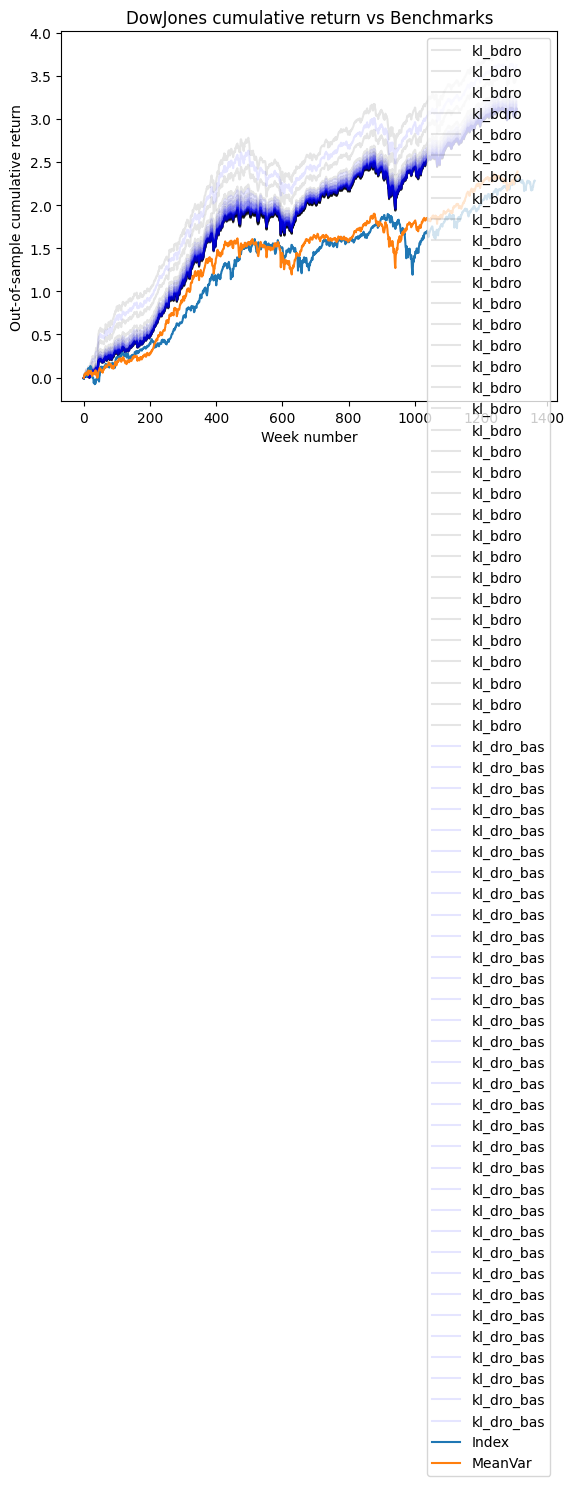

In [11]:
# dro_bas_returns = solution_returns.flatten()
for (algorithm, epsilon, num_posterior_samples), group_df in gb:
    dro_bas_returns = group_df[week_cols].values.flatten()
    plt.plot(np.cumsum(dro_bas_returns), label=algorithm, alpha=0.1, color=AlgorithmColor[algorithm].value)
plt.plot(np.cumsum(index_returns_df.values), label="Index")
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:
for baseline_model in ["MeanVar"]:
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    plt.plot(np.cumsum(baseline_returns), label=baseline_model)

plt.xlabel("Week number")
plt.ylabel("Out-of-sample cumulative return")
plt.title(dgp + r" cumulative return vs Benchmarks")
plt.legend()

In [8]:
index_returns_df

,0
0,-0.012563
1,0.018087
2,0.014025
3,0.025652
4,-0.017408
...,...
1358,0.033751
1359,0.009089
1360,0.022911
1361,-0.005020


In [9]:
num_time_windows

109